In [ ]:
import numpy as np
import matplotlib.pyplot as plt

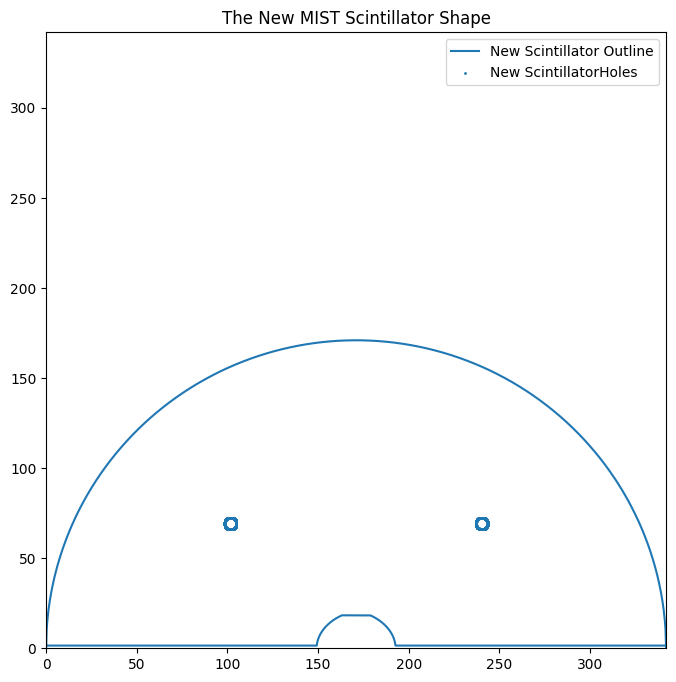

Length of Line 3: 15.69 mm at height 18.30 mm
Combined Length of Lines 2-4: 43.40 mm
Line 2 starts at a height of 1.50 mm and ends at a height of 18.30 mm
Line 4 starts at a height of 18.30 mm and ends at a height of 1.50 mm


In [ ]:
line1 = [np.linspace(0,171-21.75,1000),np.full(1000,1.5)]
xi,yi = -np.sqrt(21.75**2-1.5**2), 1.5
xf,yf = 171-15.69/2,18.3
line2 = [np.linspace(171+xi,xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(xi,-np.sqrt(21.75**2-18.3**2),1000)])]
line3 = [np.linspace(xf,171+15.69/2,1000),np.full(1000,yf)]

xf,yf = np.sqrt(21.75**2-1.5**2), 1.5
xi,yi = 171+15.69/2,18.3
line4 = [np.linspace(xi,171+xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(np.sqrt(21.75**2-18.3**2),xf,1000)])]
line5 = [np.linspace(171+21.75,342,1000),np.full(1000,1.5)]

line6 = [np.linspace(0,342,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(-171,171,1000)])]

new_scint = np.concatenate((line1, line2, line3, line4, line5, np.flip(line6, axis=1)), axis=1)

r = 3.3
circ = np.transpose(np.array([r * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)

plt.figure(figsize=(8,8))
plt.title("The New MIST Scintillator Shape")
# plt.plot(line1[0],line1[1],label="Line 1")
# plt.plot(line2[0],line2[1],label="Line 2")
# plt.plot(line3[0],line3[1],label="Line 3")
# plt.plot(line4[0],line4[1],label="Line 4")
# plt.plot(line5[0],line5[1],label="Line 5")
# plt.plot(line6[0],line6[1],label="Line 6")
# plt.plot(circ[0],circ[1],label="Circle")
plt.plot(new_scint[0],new_scint[1],label="New Scintillator Outline")
plt.scatter(holes[0],holes[1],label="New ScintillatorHoles", s=1)
plt.xlim(0,342)
plt.ylim(0,342)
plt.legend()
plt.show()

print(f"Length of Line 3: {line3[0][-1]-line3[0][0]:.2f} mm at height {line3[1][0]:.2f} mm")
print(f"Combined Length of Lines 2-4: {line4[0][-1]-line2[0][0]:.2f} mm")
print(f"Line 2 starts at a height of {line2[1][0]:.2f} mm and ends at a height of {line2[1][-1]:.2f} mm")
print(f"Line 4 starts at a height of {line4[1][0]:.2f} mm and ends at a height of {line4[1][-1]:.2f} mm")

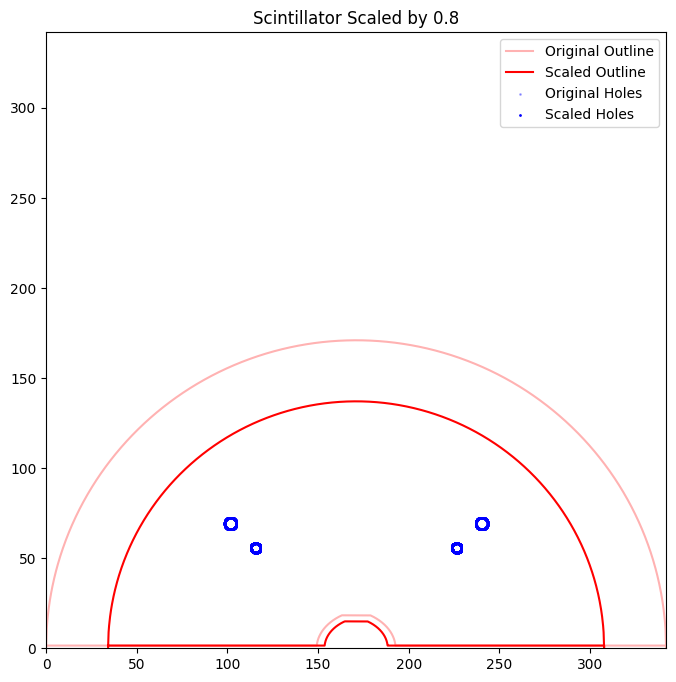

In [ ]:
target_center = np.array([171,1.5])
# Define your scaling factor (e.g., 0.8 for 80% of the original size)
scale_factor = 0.8 

# Ensure target_center is a column vector for NumPy broadcasting: shape (2, 1)
# target_center was previously defined as np.array([171, 1.5])
tc_col = target_center.reshape(2, 1)

# Apply the scaling transformation
scaled_scint = tc_col + scale_factor * (new_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- Optional: Plot to verify the scaling ---
plt.figure(figsize=(8, 8))
plt.title(f"Scintillator Scaled by {scale_factor}")
plt.plot(new_scint[0], new_scint[1], label="Original Outline", color='red', alpha=0.3)
plt.plot(scaled_scint[0], scaled_scint[1], label="Scaled Outline", color='red')
plt.scatter(holes[0], holes[1], label="Original Holes", s=1, color='blue', alpha=0.3)
plt.scatter(scaled_holes[0], scaled_holes[1], label="Scaled Holes", s=1, color='blue')
plt.xlim(0, 342)
plt.ylim(0, 342)
plt.legend()
plt.show()

Number of boxes: 117


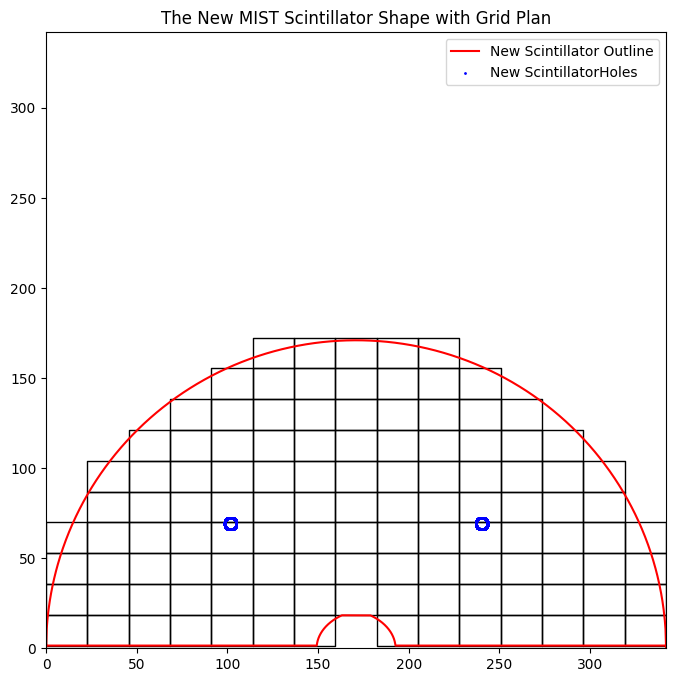

In [ ]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

rows  = 10
cols = 15
width = 342/cols
height = 171/rows
for row in range(rows):
    for col in range(cols):
        patches.append(Rectangle((col * width, row * height+1.5), width, height))

collection = PatchCollection(patches, facecolor='none', edgecolor='black')
ax.add_collection(collection)

boxes = collection.get_paths()
remove = []
for i in range(len(boxes)):
    x, y = boxes[i].vertices[0]
    x_shift = x + width
    x_c = x + width/2
    y_c = y + height/2
    if ((x_c-171)**2 + y_c**2 > 171**2):
        remove.append(i)
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        remove.append(i)

for i in reversed(remove):
    boxes.pop(i)

print(f"Number of boxes: {len(boxes)}")

plt.title("The New MIST Scintillator Shape with Grid Plan")
plt.plot(new_scint[0],new_scint[1],label="New Scintillator Outline", color='red')
plt.scatter(holes[0],holes[1],label="New ScintillatorHoles", s=1, color='blue')
plt.xlim(0, 342)
plt.ylim(0, 342)
plt.legend()
plt.show()

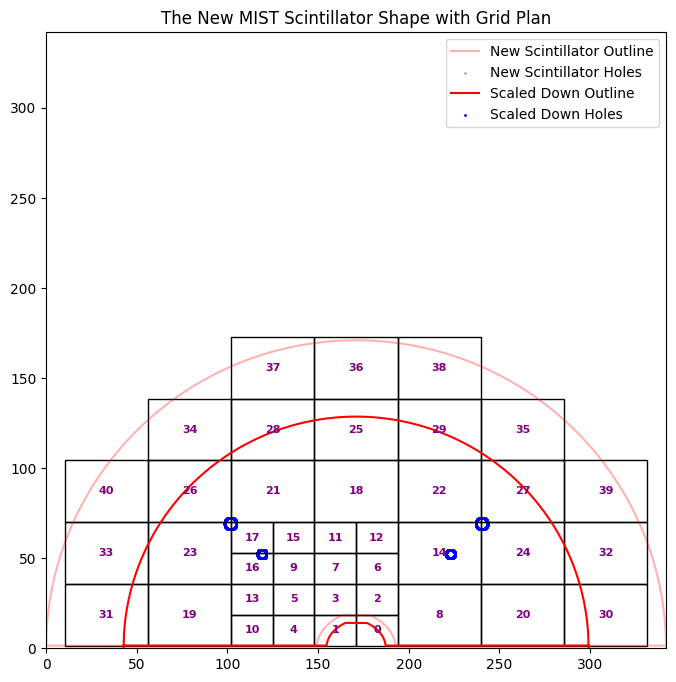

Number of boxes: 41


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
patches = []

scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(171/height)
cols = round(342/width)
centring_correction = (cols*width - 342)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        # Determine if we are in the middle-third horizontally and bottom-third vertically
        if (col > cols/centre_range and col < (round(centre_range/2))*cols/centre_range) and (row < rows/centre_range):
            
            # Base offsets for this specific grid cell
            x_base = col * width - centring_correction
            y_base = row * height + 1.5
            
            w_sub = width / 2
            h_sub = height / 2
            
            # Bottom-left sub-rectangle
            patches.append(Rectangle((x_base, y_base), w_sub, h_sub))
            # Bottom-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base), w_sub, h_sub))
            # Top-left sub-rectangle
            patches.append(Rectangle((x_base, y_base + h_sub), w_sub, h_sub))
            # Top-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base + h_sub), w_sub, h_sub))
        else:
            patches.append(Rectangle((col * width - centring_correction, row * height + 1.5), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([171, 1.5]), 170
box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

# Sort by distance from target center
box_data.sort(key=lambda item: item['distance'])

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (new_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("The New MIST Scintillator Shape with Grid Plan")
plt.plot(new_scint[0], new_scint[1], label="New Scintillator Outline", color='red',alpha=0.3)
plt.scatter(holes[0], holes[1], label="New Scintillator Holes", s=1, color='blue',alpha=0.3)
plt.plot(scaled_scint[0], scaled_scint[1], label="Scaled Down Outline", color='red')
plt.scatter(scaled_holes[0], scaled_holes[1], label="Scaled Down Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

plt.xlim(0, 342)
plt.ylim(0, 342)
plt.legend()
plt.show()

print(f"Number of boxes: {len(box_data)}")

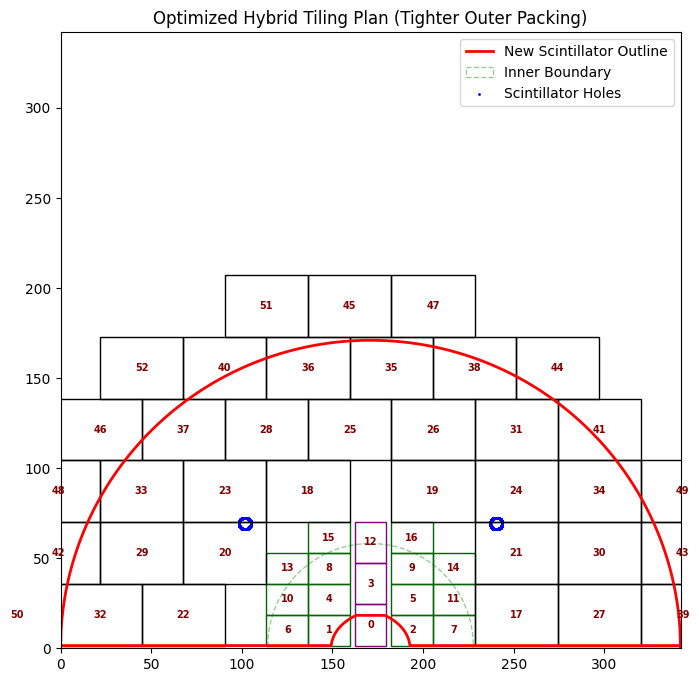

Total structured sample components initialized: 53


In [ ]:
# --- Setup and Parameters ---
target_center = np.array([171, 1.5])
target_range = 170
scale_factor = 0.8 
inner_range = target_range * (1 / 3)

# Define the box dimensions
w_large, h_large = 22.96 * 2, 17.14 * 2
w_small, h_small = 17.14, 22.96     # Only used for the 3 center columns
w_filler, h_filler = 22.96, 17.14   # Used for inner fill AND large box grid alignment

small_boxes = []
inner_unrotated_boxes = []
large_boxes = []

# --- Helper Function for Collision Detection ---
def check_overlap(box1, box2):
    """Returns True if two rectangular boxes overlap, tolerating perfectly touching edges."""
    x1, y1 = box1['xy']
    w1, h1 = box1['w'], box1['h']
    x2, y2 = box2['xy']
    w2, h2 = box2['w'], box2['h']
    
    tol = 1e-5 
    if x1 + tol >= x2 + w2 or x2 + tol >= x1 + w1:
        return False
    if y1 + tol >= y2 + h2 or y2 + tol >= y1 + h1:
        return False
    return True

# --- 1. PASS 1: EXCLUSIVELY PLACE ROTATED CENTER COLUMNS ---
small_x_starts = [171 - 0.5 * w_small]
max_small_rows = int(inner_range / h_small) + 3

for col_x in small_x_starts:
    for r in range(max_small_rows):
        x = col_x
        y = 1.5 + r * h_small
        x_c = x + w_small / 2
        y_c = y + h_small / 2
        
        if np.linalg.norm(np.array([x_c, y_c]) - target_center) <= inner_range + min(w_small, h_small)/2:
            small_boxes.append({'xy': (x, y), 'w': w_small, 'h': h_small, 'centre': (x_c, y_c)})

# --- 2. PASS 2: FILL REMAINING INNER RANGE WITH UN-ROTATED SMALL BOXES ---
cols_filler = int(342 / w_filler) + 4
rows_filler = int(171 / h_filler) + 4

for c in range(-cols_filler, cols_filler):
    for r in range(rows_filler):
        # Anchor the grid symmetrically around x=171
        x = 171 - (w_filler / 2) + c * w_filler
        y = 1.5 + r * h_filler
        x_c = x + w_filler / 2
        y_c = y + h_filler / 2
        
        # Check if center falls inside the inner zone
        if np.linalg.norm(np.array([x_c, y_c]) - target_center) <= inner_range + min(w_filler, h_filler)/2:
            candidate = {'xy': (x, y), 'w': w_filler, 'h': h_filler, 'centre': (x_c, y_c)}
            
            # Ensure it doesn't collide with the 3 rotated core columns
            if not any(check_overlap(candidate, sb) for sb in small_boxes):
                inner_unrotated_boxes.append(candidate)

# --- 3. PASS 3: PACK LARGE BOXES TIGHTLY USING THE FILLER GRID RESOLUTION ---
# Generous boundary allowance to prioritize maximizing inner density over edge clipping
outer_overlap_allowance = np.sqrt((w_large/2)**2 + (h_large/2)**2) * 1.1 

for c in range(-cols_filler, cols_filler):
    for r in range(rows_filler):
        # CRITICAL: We step by w_filler/h_filler. This lets large boxes slide 
        # seamlessly into flush contact with the un-rotated small boxes!
        x = 171 - (w_filler / 2) + c * w_filler
        y = 1.5 + r * h_filler
        x_c = x + w_large / 2
        y_c = y + h_large / 2
        x_shift = x + w_large
        
        # Outer border validation
        if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range + outer_overlap_allowance:
            continue
            
        # Strict bottom cutout safety validation
        if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
            continue
            
        candidate = {'xy': (x, y), 'w': w_large, 'h': h_large, 'centre': (x_c, y_c)}
        
        # Absolute isolation check against all previous entities
        if any(check_overlap(candidate, b) for b in small_boxes):
            continue
        if any(check_overlap(candidate, b) for b in inner_unrotated_boxes):
            continue
        if any(check_overlap(candidate, b) for b in large_boxes):
            continue
            
        large_boxes.append(candidate)

# --- 4. CONSOLIDATE AND ORDER ---
all_boxes = small_boxes + inner_unrotated_boxes + large_boxes
box_data = []

for b in all_boxes:
    x_c, y_c = b['centre']
    b['distance'] = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    box_data.append(b)

# Rainbow sort plan mapping
box_data.sort(key=lambda item: item['distance'])

# --- 5. VISUALIZATION ---
fig, ax = plt.subplots(figsize=(8, 8))
plt.title("Optimized Hybrid Tiling Plan (Tighter Outer Packing)")
plt.plot(new_scint[0], new_scint[1], label="New Scintillator Outline", color='red', linewidth=2)

# Plot the inner zone target ring
inner_circ = plt.Circle((171, 1.5), inner_range, color='green', fill=False, linestyle='--', alpha=0.4, label="Inner Boundary")
ax.add_patch(inner_circ)
plt.scatter(holes[0], holes[1], label="Scintillator Holes", s=1, color='blue')

# Render out categories with distinct outlines to easily inspect layout structure
for box_id, data in enumerate(box_data):
    x, y = data['xy']
    w, h = data['w'], data['h']
    x_c, y_c = data['centre']
    
    # Custom color scheme to trace execution behavior
    if data in small_boxes:
        edge_color = 'purple'  # The 3 core rotated columns
    elif data in inner_unrotated_boxes:
        edge_color = 'darkgreen' # Rest of the inner range
    else:
        edge_color = 'black'     # Massive high-density outer fill
        
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor=edge_color)
    ax.add_patch(rect)
    ax.text(x_c, y_c, str(box_id), color='maroon', fontsize=7, ha='center', va='center', weight='bold')

plt.xlim(0, 342)
plt.ylim(0, 342)
plt.legend(loc="upper right")
plt.show()

print(f"Total structured sample components initialized: {len(box_data)}")

In [ ]:
from scipy.constants import pi
from scipy.integrate import quad
import numpy as np

event_rate = 1.97
min_samp_dur = 180

r_hole = 3.3
r = 21.75
R = 171
h = 1.5
H = 18.3
l = 15.69
L = 342

# --- Geometric Scintillator Area Calculations ---
hole_area = pi * r_hole**2
semi_circle_area = pi * R**2 / 2

x1, x2 = R - np.sqrt(R**2 - h**2), r - np.sqrt(r**2 - h**2)
bottom_area = (L - 2 * x1) * h + 2 * quad(lambda x: np.sqrt(R**2 - (x-R)**2), 0, x1)[0]
cutout_area = pi * r**2 / 2 - quad(lambda x: np.sqrt(r**2 - (x)**2), -l/2, l/2)[0] + H * l
overlap = (2*r - 2 * x2) * h + 2 * quad(lambda x: np.sqrt(r**2 - (x-r)**2), 0, x2)[0]

scint_area = semi_circle_area - 2 * hole_area - cutout_area - bottom_area + overlap

# --- NEW: Compute True Dynamic Area Metrics ---
# Sum up the exact area (w * h) of every filtered box in your box_data list
total_measurement_area = sum(data['w'] * data['h'] for data in box_data)

# Calculate the average box size across your mixed grid
n_samp = len(box_data)
avg_samp_area = total_measurement_area / n_samp

# Print results using the accurate area metrics
print(f"Scintillator Area: {scint_area/1e2:.2f} cm^2")
print(f"Average Sample Area: {avg_samp_area / 1e2:.2f} cm^2")
print(f"Total Measurement Area: {total_measurement_area / 1e2:.2f} cm^2")
print()

# Scale recording factor using the true average sample size
duration_scaling_factor = scint_area / avg_samp_area
expected_event_rate = (avg_samp_area / scint_area) * event_rate
avg_recording_time_per_sample = min_samp_dur * duration_scaling_factor
total_recording_time = avg_recording_time_per_sample * n_samp

print(f"Expected Event Rate for a normal sample (assuming 100% efficiency): ~{expected_event_rate:.2f} events/s")
print(f"To get the same number of events as the full scintillator, we would need an average sample duration {duration_scaling_factor:.2f} times longer than usual")
print(f"Assuming that the minimum sample duration for the full scintillator (TBD) is {min_samp_dur} s, we will need to record for an average of {avg_recording_time_per_sample:.0f} s ≈ {avg_recording_time_per_sample / 60:.0f} min per sample")
print(f"This implies that recording all active grid elements will take {total_recording_time:.0f} s ≈ {total_recording_time / 60:.0f} min ≈ {total_recording_time / 3600:.2f} h ≈ {total_recording_time / 86400:.2f} days")

Scintillator Area: 447.19 cm^2
Average Sample Area: 11.13 cm^2
Total Measurement Area: 456.50 cm^2

Expected Event Rate for a normal sample (assuming 100% efficiency): ~0.05 events/s
To get the same number of events as the full scintillator, we would need an average sample duration 40.16 times longer than usual
Assuming that the minimum sample duration for the full scintillator (TBD) is 180 s, we will need to record for an average of 7229 s ≈ 120 min per sample
This implies that recording all active grid elements will take 296409 s ≈ 4940 min ≈ 82.34 h ≈ 3.43 days


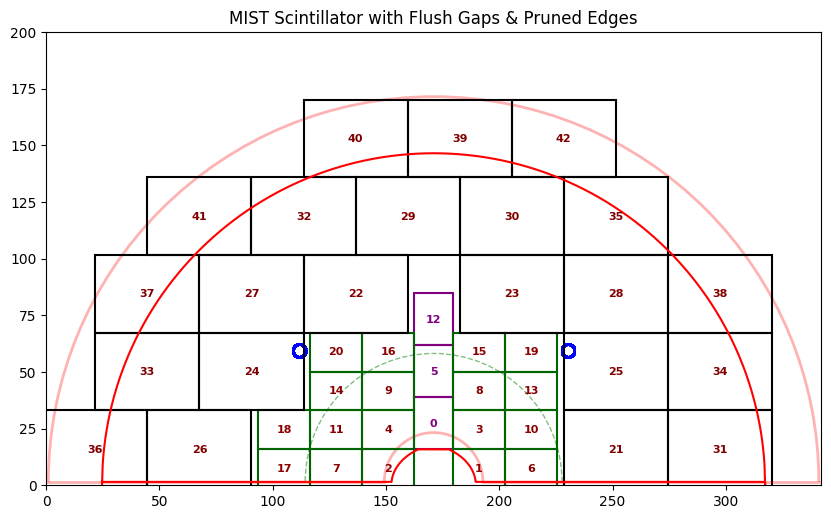

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Setup and Parameters ---
target_center = np.array([171, 1.5])
target_range = 170
scale_factor = 154/171 * 0.95
inner_range = target_range * (1 / 3)

# Define the box dimensions
w_large, h_large = 22.96 * 2, 17.14 * 2
w_small, h_small = 17.14, 22.96     # Only used for the 3 center columns
w_filler, h_filler = 22.96, 17.14   # Used for inner fill AND large box grid alignment

small_boxes = []
inner_unrotated_boxes = []
large_boxes = []

# --- Helper Function for Collision Detection ---
def check_overlap(box1, box2):
    """Returns True if two rectangular boxes overlap, tolerating perfectly touching edges."""
    x1, y1 = box1['xy']
    w1, h1 = box1['w'], box1['h']
    x2, y2 = box2['xy']
    w2, h2 = box2['w'], box2['h']
    
    tol = 1e-5 
    if x1 + tol >= x2 + w2 or x2 + tol >= x1 + w1:
        return False
    if y1 + tol >= y2 + h2 or y2 + tol >= y1 + h1:
        return False
    return True

# --- 1. PASS 1: EXCLUSIVELY PLACE ROTATED CENTER COLUMNS ---
small_x_starts = [171 - 0.5 * w_small]
max_small_rows = int(inner_range / h_small) + 3

for col_x in small_x_starts:
    for r in range(max_small_rows):
        x = col_x
        y = 1.5 + r * h_small
        x_c = x + w_small / 2
        y_c = y + h_small / 2
        
        if np.linalg.norm(np.array([x_c, y_c]) - target_center) <= inner_range + min(w_small, h_small)/2:
            small_boxes.append({'xy': (x, y), 'w': w_small, 'h': h_small, 'centre': (x_c, y_c)})

# --- 2. PASS 2: FILL REMAINING INNER RANGE WITH UN-ROTATED SMALL BOXES ---
cols_filler = int(342 / w_filler) + 4
rows_filler = int(171 / h_filler) + 4

for c in range(-cols_filler, cols_filler):
    for r in range(rows_filler):
        # Anchor the grid symmetrically around x=171
        x = 171 - (w_filler / 2) + c * w_filler
        y = 1.5 + r * h_filler
        x_c = x + w_filler / 2
        y_c = y + h_filler / 2
        
        # Check if center falls inside the inner zone
        if np.linalg.norm(np.array([x_c, y_c]) - target_center) <= inner_range + min(w_filler, h_filler)/2:
            candidate = {'xy': (x, y), 'w': w_filler, 'h': h_filler, 'centre': (x_c, y_c)}
            
            # Ensure it doesn't collide with the 3 rotated core columns
            if not any(check_overlap(candidate, sb) for sb in small_boxes):
                inner_unrotated_boxes.append(candidate)

# --- 3. PASS 3: PACK LARGE BOXES TIGHTLY USING THE FILLER GRID RESOLUTION ---
# Generous boundary allowance to prioritize maximizing inner density over edge clipping
outer_overlap_allowance = np.sqrt((w_large/2)**2 + (h_large/2)**2) * 1.1 

for c in range(-cols_filler, cols_filler):
    for r in range(rows_filler):
        # CRITICAL: We step by w_filler/h_filler. This lets large boxes slide 
        # seamlessly into flush contact with the un-rotated small boxes!
        x = 171 - (w_filler / 2) + c * w_filler
        y = 1.5 + r * h_filler
        x_c = x + w_large / 2
        y_c = y + h_large / 2
        x_shift = x + w_large
        
        # Outer border validation
        if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range + outer_overlap_allowance:
            continue
            
        # Strict bottom cutout safety validation
        if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
            continue
            
        candidate = {'xy': (x, y), 'w': w_large, 'h': h_large, 'centre': (x_c, y_c)}
        
        # Absolute isolation check against all previous entities
        if any(check_overlap(candidate, b) for b in small_boxes):
            continue
        if any(check_overlap(candidate, b) for b in inner_unrotated_boxes):
            continue
        if any(check_overlap(candidate, b) for b in large_boxes):
            continue
            
        large_boxes.append(candidate)

# --- 4. NEW PASS 4: REMOVE INNER UNROTATED & REFILL FLUSH GAPS ---
# Clear out all the previously placed small unrotated boxes
inner_unrotated_boxes.clear()

cols_fill_all = int(target_range / w_filler) + 2
rows_fill_all = int(target_range / h_filler) + 2
gap_fill_allowance = np.sqrt((w_filler/2)**2 + (h_filler/2)**2) * 1.1 

for r in range(rows_fill_all):
    y = 1.5 + r * h_filler
    y_c = y + h_filler / 2
    
    for c in range(cols_fill_all):
        # 1. Expand RIGHT starting exactly flush with the center column's right edge
        x_right = 171 + (w_small / 2) + c * w_filler
        x_c_right = x_right + w_filler / 2
        candidate_right = {'xy': (x_right, y), 'w': w_filler, 'h': h_filler, 'centre': (x_c_right, y_c)}
        
        if np.linalg.norm(np.array([x_c_right, y_c]) - target_center) <= target_range + gap_fill_allowance:
            x_shift_right = x_right + w_filler
            if not (y == 1.5 and (x_right > 171-21.75 and x_right < 171+21.75) and (x_shift_right > 171-21.75 and x_shift_right < 171+21.75)):
                if not any(check_overlap(candidate_right, b) for b in small_boxes + large_boxes + inner_unrotated_boxes):
                    inner_unrotated_boxes.append(candidate_right)
                    
        # 2. Expand LEFT starting exactly flush with the center column's left edge
        x_left = 171 - (w_small / 2) - (c + 1) * w_filler
        x_c_left = x_left + w_filler / 2
        candidate_left = {'xy': (x_left, y), 'w': w_filler, 'h': h_filler, 'centre': (x_c_left, y_c)}
        
        if np.linalg.norm(np.array([x_c_left, y_c]) - target_center) <= target_range + gap_fill_allowance:
            x_shift_left = x_left + w_filler
            if not (y == 1.5 and (x_left > 171-21.75 and x_left < 171+21.75) and (x_shift_left > 171-21.75 and x_shift_left < 171+21.75)):
                if not any(check_overlap(candidate_left, b) for b in small_boxes + large_boxes + inner_unrotated_boxes):
                    inner_unrotated_boxes.append(candidate_left)

# --- 5. NEW PASS 5: PRUNE LARGE BOXES WITH LOW OVERLAP ---
# Keep only the large boxes whose center falls within the scintillator boundary
large_boxes = [b for b in large_boxes if np.linalg.norm(np.array(b['centre']) - target_center) <= target_range]

# --- 6. CONSOLIDATE AND ORDER ---
all_boxes = small_boxes + inner_unrotated_boxes + large_boxes
box_data = []

for b in all_boxes:
    x_c, y_c = b['centre']
    b['distance'] = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    box_data.append(b)

# Sort plan mapping by distance from center
box_data.sort(key=lambda item: item['distance'])

# --- 7. MISC ---

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (new_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- Shift All Boxes Down ---
shift_1 = -(w_small - scale_factor * (18.3-1.5))
shift_2 = scale_factor * (18.3-1.5)

for b in box_data:
    # Check if the box is NOT a small, rotated box
    if b['w'] != w_small:
        shift = shift_1
    else:
        shift = shift_2
    # Update the bottom-left corner coordinates
    x, y = b['xy']
    b['xy'] = (x, y + shift)
        
    # Update the center coordinates
    x_c, y_c = b['centre']
    b['centre'] = (x_c, y_c + shift)

# --- 8. PLOTTING THE RESULT ---
fig, ax = plt.subplots(figsize=(10, 8))

# Draw bounding geometry
outer_circle = patches.Arc((171, 1.5), target_range*2, target_range*2, theta1=0, theta2=180, edgecolor='red', lw=2, alpha = 0.3)
ax.add_patch(outer_circle)
inner_cutout = patches.Arc((171, 1.5), 21.75*2, 21.75*2, theta1=0, theta2=180, edgecolor='red', lw=2, alpha = 0.3)
ax.add_patch(inner_cutout)
plt.plot([171-target_range, 171-21.75], [1.5, 1.5], color='red', lw=2, alpha = 0.3)
plt.plot([171+21.75, 171+target_range], [1.5, 1.5], color='red', lw=2, alpha = 0.3)
plt.plot(scaled_scint[0], scaled_scint[1], label="Scaled Down Outline", color='red')
plt.scatter(scaled_holes[0], scaled_holes[1], label="Scaled Down Holes", s=1, color='blue')

# Draw inner threshold reference line
inner_arc = patches.Arc((171, 1.5), inner_range*2, inner_range*2, theta1=0, theta2=180, edgecolor='green', lw=1, linestyle='--', alpha=0.5)
ax.add_patch(inner_arc)

# Plot generated boxes
for i, b in enumerate(box_data):
    w, h = b['w'], b['h']
    
    # Determine color styling based on box properties
    if w == w_large:
        edgecolor = 'black'
        font_color = 'maroon'
    elif w == w_small:
        edgecolor = 'purple'
        font_color = 'purple'
    else:
        edgecolor = 'darkgreen'
        font_color = 'darkred'
        
    rect = patches.Rectangle(b['xy'], w, h, linewidth=1.5, edgecolor=edgecolor, facecolor='none')
    ax.add_patch(rect)
    plt.text(b['centre'][0], b['centre'][1], str(i), color=font_color, ha='center', va='center', fontsize=8, fontweight='bold')

plt.xlim(0, 342)
plt.ylim(0, 200)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("MIST Scintillator with Flush Gaps & Pruned Edges")
plt.show()



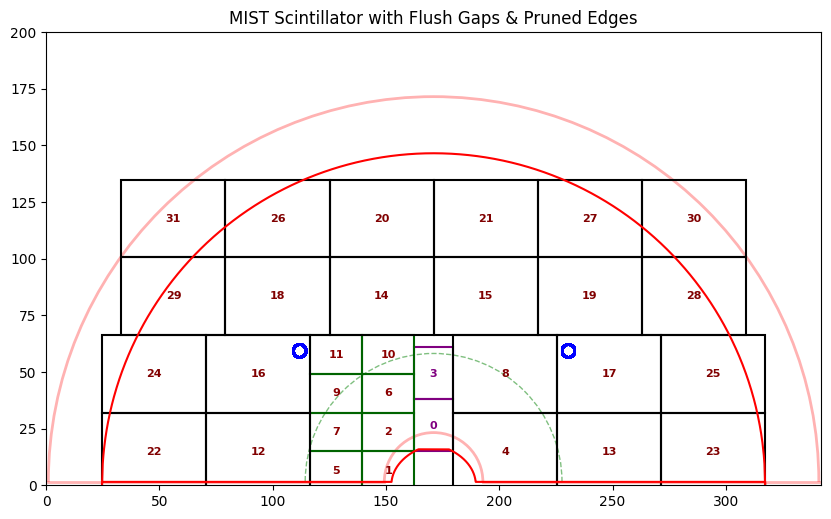

In [ ]:
import matplotlib.patches as patches

# --- Setup and Parameters ---
target_center = np.array([171, 1.5])
target_range = 170

w_large, h_large = 45.92, 34.28
w_small, h_small = 17.14, 22.96     
w_filler, h_filler = 22.96, 17.14   

scale_factor = 0.8 

# --- Hardcoded Box Placements (Pre-shift Coordinates) ---
box_data = []

# 1. Purple Boxes (Centered at X=171)
# Box 12 (top) is removed.
box_data.extend([
    {'xy': (162.43, 1.5), 'w': w_small, 'h': h_small},
    {'xy': (162.43, 24.46), 'w': w_small, 'h': h_small}
])

# 2. Green Boxes (Left side only + new center gap box)
# Right side green boxes were replaced by large boxes. Boxes 17 and 18 are removed.
box_data.extend([
    # Inner Left Column (x=139.47)
    {'xy': (139.47, 1.5), 'w': w_filler, 'h': h_filler},
    {'xy': (139.47, 18.64), 'w': w_filler, 'h': h_filler},
    {'xy': (139.47, 35.78), 'w': w_filler, 'h': h_filler},
    {'xy': (139.47, 52.92), 'w': w_filler, 'h': h_filler},
    
    # Outer Left Column (x=116.51)
    {'xy': (116.51, 1.5), 'w': w_filler, 'h': h_filler},
    {'xy': (116.51, 18.64), 'w': w_filler, 'h': h_filler},
    {'xy': (116.51, 35.78), 'w': w_filler, 'h': h_filler},
    
    # New Green Box in center gap
    # Placed at y=87.50 so it slightly overlaps the large box above it (y=104.34) after the shift
    # {'xy': (159.52, 87.50), 'w': w_filler, 'h': h_filler} 
])

# 3. Large Boxes
# Row Level 4 (Boxes 39, 40, 42) is removed entirely.
box_data.extend([
    # Level 0 (y=1.5): Packed against green boxes on the left
    {'xy': (24.67, 1.5), 'w': w_large, 'h': h_large},
    {'xy': (70.59, 1.5), 'w': w_large, 'h': h_large},
    {'xy': (179.57, 1.5), 'w': w_large, 'h': h_large}, # Replaces right green boxes (1, 3, 6, 10)
    {'xy': (225.49, 1.5), 'w': w_large, 'h': h_large},
    {'xy': (271.41, 1.5), 'w': w_large, 'h': h_large},
    
    # Level 1 (y=35.78): Packed against green boxes on the left
    {'xy': (171-2*h_small-w_small/2, 35.78+w_small), 'w': h_small, 'h': w_small}, # Missing green box
    {'xy': (24.67, 35.78), 'w': w_large, 'h': h_large},
    {'xy': (70.59, 35.78), 'w': w_large, 'h': h_large},
    {'xy': (179.57, 35.78), 'w': w_large, 'h': h_large}, # Replaces right green boxes (8, 13, 15, 19)
    {'xy': (225.49, 35.78), 'w': w_large, 'h': h_large},
    {'xy': (271.41, 35.78), 'w': w_large, 'h': h_large},

    # # Level 2 (y=70.06): Centered row mapping (includes boxes 22 & 23 touching the outer large boxes)
    # {'xy': (21.76, 70.06), 'w': w_large, 'h': h_large},
    # {'xy': (67.68, 70.06), 'w': w_large, 'h': h_large},
    # {'xy': (113.60, 70.06), 'w': w_large, 'h': h_large}, # Former Box 22
    # {'xy': (182.48, 70.06), 'w': w_large, 'h': h_large}, # Former Box 23
    # {'xy': (228.40, 70.06), 'w': w_large, 'h': h_large},
    # {'xy': (274.32, 70.06), 'w': w_large, 'h': h_large},

    # Level 2 (y=70.06): Centered row mapping (includes boxes 22 & 23 touching the outer large boxes)
    {'xy': (33.24, 70.06), 'w': w_large, 'h': h_large},
    {'xy': (79.16, 70.06), 'w': w_large, 'h': h_large},
    {'xy': (125.08, 70.06), 'w': w_large, 'h': h_large}, # Former Box 22
    {'xy': (171.0, 70.06), 'w': w_large, 'h': h_large}, # Former Box 23
    {'xy': (216.92, 70.06), 'w': w_large, 'h': h_large},
    {'xy': (262.84, 70.06), 'w': w_large, 'h': h_large},


    # Level 3 (y=104.34): Centered contiguous row
    {'xy': (33.24, 104.34), 'w': w_large, 'h': h_large},
    {'xy': (79.16, 104.34), 'w': w_large, 'h': h_large},
    {'xy': (125.08, 104.34), 'w': w_large, 'h': h_large}, # Former Box 29
    {'xy': (171.0, 104.34), 'w': w_large, 'h': h_large},
    {'xy': (216.92, 104.34), 'w': w_large, 'h': h_large},
    {'xy': (262.84, 104.34), 'w': w_large, 'h': h_large}
])

# --- 4. Calculate Centers & Sort ---
for b in box_data:
    b['centre'] = (b['xy'][0] + b['w']/2, b['xy'][1] + b['h']/2)
    b['distance'] = np.linalg.norm(np.array(b['centre']) - target_center)

box_data.sort(key=lambda item: item['distance'])

# --- 5. Apply User Shift Logic ---
shift_1 = -(w_small - scale_factor * (18.3-1.5))
shift_2 = scale_factor * (18.3-1.5)

for b in box_data:
    if b['w'] != w_small:
        shift = shift_1
    else:
        shift = shift_2
        
    x, y = b['xy']
    b['xy'] = (x, y + shift)
        
    x_c, y_c = b['centre']
    b['centre'] = (x_c, y_c + shift)

# --- 8. PLOTTING THE RESULT ---
fig, ax = plt.subplots(figsize=(10, 8))

# Draw bounding geometry
outer_circle = patches.Arc((171, 1.5), target_range*2, target_range*2, theta1=0, theta2=180, edgecolor='red', lw=2, alpha = 0.3)
ax.add_patch(outer_circle)
inner_cutout = patches.Arc((171, 1.5), 21.75*2, 21.75*2, theta1=0, theta2=180, edgecolor='red', lw=2, alpha = 0.3)
ax.add_patch(inner_cutout)
plt.plot([171-target_range, 171-21.75], [1.5, 1.5], color='red', lw=2, alpha = 0.3)
plt.plot([171+21.75, 171+target_range], [1.5, 1.5], color='red', lw=2, alpha = 0.3)
plt.plot(scaled_scint[0], scaled_scint[1], label="Scaled Down Outline", color='red')
plt.scatter(scaled_holes[0], scaled_holes[1], label="Scaled Down Holes", s=1, color='blue')

# Draw inner threshold reference line
inner_arc = patches.Arc((171, 1.5), inner_range*2, inner_range*2, theta1=0, theta2=180, edgecolor='green', lw=1, linestyle='--', alpha=0.5)
ax.add_patch(inner_arc)

# Plot generated boxes
for i, b in enumerate(box_data):
    w, h = b['w'], b['h']
    
    # Determine color styling based on box properties
    if w == w_large:
        edgecolor = 'black'
        font_color = 'maroon'
    elif w == w_small:
        edgecolor = 'purple'
        font_color = 'purple'
    else:
        edgecolor = 'darkgreen'
        font_color = 'darkred'
        
    rect = patches.Rectangle(b['xy'], w, h, linewidth=1.5, edgecolor=edgecolor, facecolor='none')
    ax.add_patch(rect)
    plt.text(b['centre'][0], b['centre'][1], str(i), color=font_color, ha='center', va='center', fontsize=8, fontweight='bold')

plt.xlim(0, 342)
plt.ylim(0, 200)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("MIST Scintillator with Flush Gaps & Pruned Edges")
plt.show()

In [ ]:
id = 0

print("      | Horizontal Distance |   Vertical distance   |  Size of  |          |")
print("  ID  | from Left Edge (mm) | from Bottom Edge (mm) | Rectangle | Rotation |")
print("------+---------------------+-----------------------+-----------+----------|")

for box in box_data:
    x, y = box['xy']
    w, h = box['w'], box['h']
    rot = False
    if w == width:
        size='Large'
    elif w == width/2:
        size='Small'
    elif w == height/2:
        size='Small'
        rot=True
    else:
        size='Unknown'
    print(f" {id:4d} | {x:19.1f} | {y-1.5:21.1f} | {size:>9} | {"90°" if rot else "0°":>8} |")
    id+=1

      | Horizontal Distance |   Vertical distance   |  Size of  |          |
  ID  | from Left Edge (mm) | from Bottom Edge (mm) | Rectangle | Rotation |
------+---------------------+-----------------------+-----------+----------|
    0 |               162.4 |                  13.4 |     Small |      90° |
    1 |               139.5 |                  -3.7 |     Small |       0° |
    2 |               139.5 |                  13.4 |     Small |       0° |
    3 |               162.4 |                  36.4 |     Small |      90° |
    4 |               179.6 |                  -3.7 |     Large |       0° |
    5 |               116.5 |                  -3.7 |     Small |       0° |
    6 |               139.5 |                  30.6 |     Small |       0° |
    7 |               116.5 |                  13.4 |     Small |       0° |
    8 |               179.6 |                  30.6 |     Large |       0° |
    9 |               116.5 |                  30.6 |     Small |       0° |

In [ ]:
from scipy.constants import pi
from scipy.integrate import quad
import numpy as np

event_rate = 1.97
min_samp_dur = 180

r_hole = 3.3
r = 21.75
R = 171
h = 1.5
H = 18.3
l = 15.69
L = 342

# --- Geometric Scintillator Area Calculations ---
hole_area = pi * r_hole**2
semi_circle_area = pi * R**2 / 2

x1, x2 = R - np.sqrt(R**2 - h**2), r - np.sqrt(r**2 - h**2)
bottom_area = (L - 2 * x1) * h + 2 * quad(lambda x: np.sqrt(R**2 - (x-R)**2), 0, x1)[0]
cutout_area = pi * r**2 / 2 - quad(lambda x: np.sqrt(r**2 - (x)**2), -l/2, l/2)[0] + H * l
overlap = (2*r - 2 * x2) * h + 2 * quad(lambda x: np.sqrt(r**2 - (x-r)**2), 0, x2)[0]

scint_area = semi_circle_area - 2 * hole_area - cutout_area - bottom_area + overlap

# --- NEW: Compute True Dynamic Area Metrics ---
# Sum up the exact area (w * h) of every filtered box in your box_data list
total_measurement_area = sum(data['w'] * data['h'] for data in box_data)

# Calculate the average box size across your mixed grid
n_samp = len(box_data)
avg_samp_area = total_measurement_area / n_samp

# Print results using the accurate area metrics
print(f"Scintillator Area: {scint_area/1e2:.2f} cm^2")
print(f"Average Sample Area: {avg_samp_area / 1e2:.2f} cm^2")
print(f"Total Measurement Area: {total_measurement_area / 1e2:.2f} cm^2")
print()

# Scale recording factor using the true average sample size
duration_scaling_factor = scint_area / avg_samp_area
expected_event_rate = (avg_samp_area / scint_area) * event_rate
avg_recording_time_per_sample = min_samp_dur * duration_scaling_factor
total_recording_time = avg_recording_time_per_sample * n_samp

print(f"Expected Event Rate for a normal sample (assuming 100% efficiency): ~{expected_event_rate:.2f} events/s")
print(f"To get the same number of events as the full scintillator, we would need an average sample duration {duration_scaling_factor:.2f} times longer than usual")
print(f"Assuming that the minimum sample duration for the full scintillator (TBD) is {min_samp_dur} s, we will need to record for an average of {avg_recording_time_per_sample:.0f} s ≈ {avg_recording_time_per_sample / 60:.0f} min per sample")
print(f"This implies that recording all active grid elements will take {total_recording_time:.0f} s ≈ {total_recording_time / 60:.0f} min ≈ {total_recording_time / 3600:.2f} h ≈ {total_recording_time / 86400:.2f} days")

Scintillator Area: 447.19 cm^2
Average Sample Area: 12.05 cm^2
Total Measurement Area: 385.66 cm^2

Expected Event Rate for a normal sample (assuming 100% efficiency): ~0.05 events/s
To get the same number of events as the full scintillator, we would need an average sample duration 37.11 times longer than usual
Assuming that the minimum sample duration for the full scintillator (TBD) is 180 s, we will need to record for an average of 6679 s ≈ 111 min per sample
This implies that recording all active grid elements will take 213725 s ≈ 3562 min ≈ 59.37 h ≈ 2.47 days


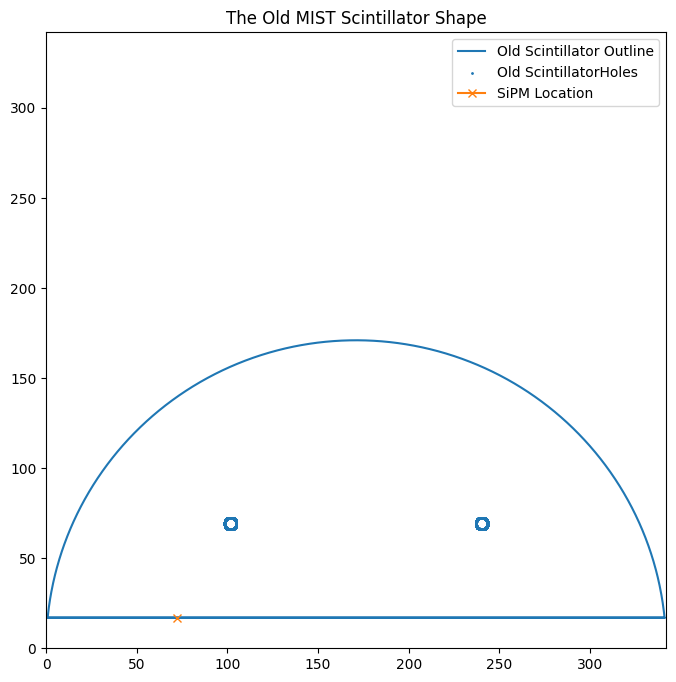

Length of Line 3: 340.31 mm at height 17.00 mm
Combined Length of Lines 2-4: 191.85 mm
Line 2 starts at a height of 17.00 mm and ends at a height of 17.00 mm
Line 4 starts at a height of 18.30 mm and ends at a height of 1.50 mm


In [ ]:
def circle(radius):
   return np.transpose(np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))

R = 171
h = 17

xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
line1 = [np.linspace(xi,xf,1000),np.full(1000,h)]

line2 = [np.linspace(xi,xf,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(xi-R,xf-R,1000)])]

old_scint = np.concatenate((line1, line2), axis=1)

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)

SiPM_loc = [65+7,h]

plt.figure(figsize=(8,8))
plt.title("The Old MIST Scintillator Shape")
# plt.plot(line1[0],line1[1],label="Line 1")
# plt.plot(line2[0],line2[1],label="Line 2")
# plt.plot(line3[0],line3[1],label="Line 3")
# plt.plot(line4[0],line4[1],label="Line 4")
# plt.plot(line5[0],line5[1],label="Line 5")
# plt.plot(line6[0],line6[1],label="Line 6")
# plt.plot(circ[0],circ[1],label="Circle")
plt.plot(old_scint[0],old_scint[1],label="Old Scintillator Outline")
plt.scatter(holes[0],holes[1],label="Old ScintillatorHoles", s=1)
plt.plot(SiPM_loc[0],SiPM_loc[1],marker='x',label="SiPM Location")
ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

print(f"Length of Line 3: {line3[0][-1]-line3[0][0]:.2f} mm at height {line3[1][0]:.2f} mm")
print(f"Combined Length of Lines 2-4: {line4[0][-1]-line2[0][0]:.2f} mm")
print(f"Line 2 starts at a height of {line2[1][0]:.2f} mm and ends at a height of {line2[1][-1]:.2f} mm")
print(f"Line 4 starts at a height of {line4[1][0]:.2f} mm and ends at a height of {line4[1][-1]:.2f} mm")

30


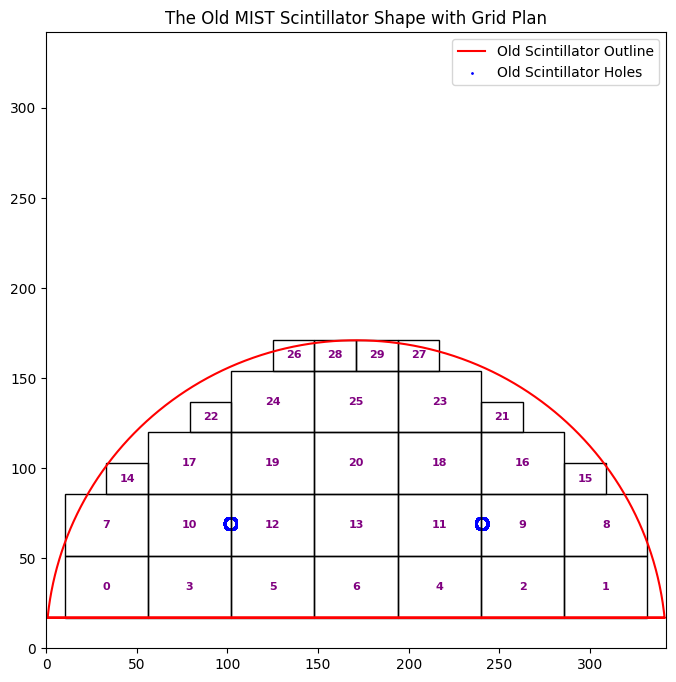

Number of boxes: 30


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
patches = []

R,h = 171, 17

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - 2*R)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        dist = np.linalg.norm([x_c,y_c] - target_center)
        if dist>tolerance*R:
            if col == int(cols/2):
                patches.append(Rectangle((x,y), width/2, height/2))
                patches.append(Rectangle((x+width/2,y), width/2, height/2))
            elif x < R:
                patches.append(Rectangle((x+width/2,y), width/2, height/2))
            else:
                patches.append(Rectangle((x,y), width/2, height/2))
        else:
            patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R-1
box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

print(len(box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (old_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("The Old MIST Scintillator Shape with Grid Plan")
plt.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

print(f"Number of boxes: {len(box_data)}")